# ✈ AI-Powered Route Optimizer ✈

### Core Idea

- Flight dispatchers manually analyze weather charts, wind vectors, and air traffic congestion to map out routes.
- This project uses ML to predict the most fuel-efficient and turbulent-free flight paths.

### The Project Concept

Let's say that there is a flight from Airport A (Jakarta - CGK) to Airport B (Surabaya - SUB). Between these airports, there are several airway waypoints. Some waypoints have strong headwinds (which slow the plane down and burn more fuel) or severe weather.

In this project, we will use Python to:
- Predict the fuel-burn cost for every airway segment based on simulated wind and weather.
- Calculate the absolute most fuel-efficient route from Jakarta to Surabaya using Dijkstra's Algorithm.

### Create the Simulated Waypoint Network & Data

First we will generate a synthetic network of flight waypoints between Jakarta and Surabaya, along with 500 records of historical weather conditions and fuel burn.

In [ ]:
import pandas as pd
import numpy as np

# Set random seed for identical results
np.random.seed(42)
num_samples = 500

# Simulate Historical Weather & Fuel Burn Data for Airway Segments
# Features: Headwind component (knots), Turbulence level (1-5), Distance (nautical miles)
headwind = np.random.uniform(-20, 60, size=num_samples) # Negative means tailwind
turbulence = np.random.randint(1, 6, size=num_samples)
distance_nm = np.random.choice([100, 120, 150, 180], size=num_samples)

# Formula for base fuel burn (in kg) + penalties for wind and avoiding turbulence
base_fuel = distance_nm * 12
wind_penalty = headwind * 3.5
turb_penalty = turbulence * 40
actual_fuel_burn = base_fuel + wind_penalty + turb_penalty + np.random.normal(0, 15, size=num_samples)

df_routes = pd.DataFrame({
    'headwind_knots': headwind,
    'turbulence_level': turbulence,
    'distance_nm': distance_nm,
    'fuel_burn_kg': np.round(actual_fuel_burn, 1)
})

df_routes.to_csv("historical_route_fuel.csv", index=False)
print("✅ Flight segment data saved as 'historical_route_fuel.csv'")
print(df_routes.head())

✅ Flight segment data saved as 'historical_route_fuel.csv'
   headwind_knots  turbulence_level  distance_nm  fuel_burn_kg
0        9.963210                 1          150        1874.2
1       56.057145                 1          120        1684.5
2       38.559515                 1          150        1966.8
3       27.892679                 5          120        1747.2
4       -7.518509                 4          150        1957.2


### Data Visualization and Analysis

After generating the dataset, let's visualize the distributions of the features (`headwind_knots`, `turbulence_level`, `distance_nm`) and their relationship with the target variable (`fuel_burn_kg`). This will help us understand the synthetic data and confirm if it aligns with our expectations.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import joblib

# Load data
df = pd.read_csv("historical_route_fuel.csv")

print("Dataset head:")
print(df.head())

print("\nDataset info:")
df.info()

print("\nDataset description:")
print(df.describe())

Dataset head:
   headwind_knots  turbulence_level  distance_nm  fuel_burn_kg
0        9.963210                 1          150        1874.2
1       56.057145                 1          120        1684.5
2       38.559515                 1          150        1966.8
3       27.892679                 5          120        1747.2
4       -7.518509                 4          150        1957.2

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   headwind_knots    500 non-null    float64
 1   turbulence_level  500 non-null    int64  
 2   distance_nm       500 non-null    int64  
 3   fuel_burn_kg      500 non-null    float64
dtypes: float64(2), int64(2)
memory usage: 15.8 KB

Dataset description:
       headwind_knots  turbulence_level  distance_nm  fuel_burn_kg
count      500.000000        500.000000   500.000000    500.000000


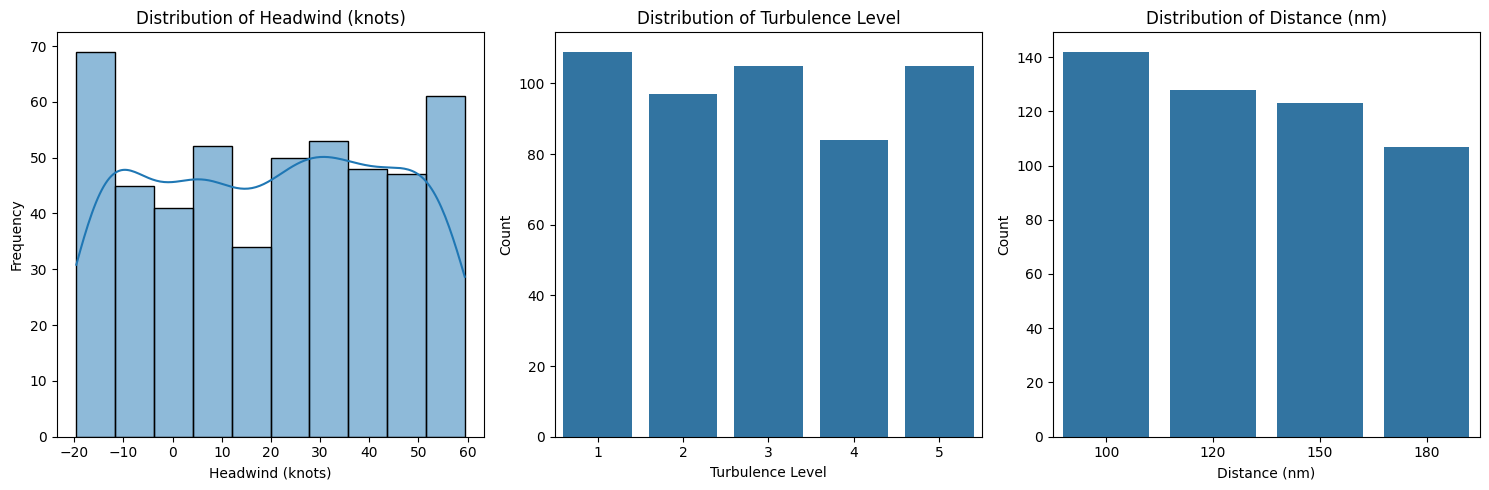

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 5))

# Distribution of headwind_knots
plt.subplot(1, 3, 1)
sns.histplot(df['headwind_knots'], kde=True)
plt.title('Distribution of Headwind (knots)')
plt.xlabel('Headwind (knots)')
plt.ylabel('Frequency')

# Distribution of turbulence_level
plt.subplot(1, 3, 2)
sns.countplot(x=df['turbulence_level'])
plt.title('Distribution of Turbulence Level')
plt.xlabel('Turbulence Level')
plt.ylabel('Count')

# Distribution of distance_nm
plt.subplot(1, 3, 3)
sns.countplot(x=df['distance_nm'])
plt.title('Distribution of Distance (nm)')
plt.xlabel('Distance (nm)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

Now, let's look at the relationship between these features and the `fuel_burn_kg`.

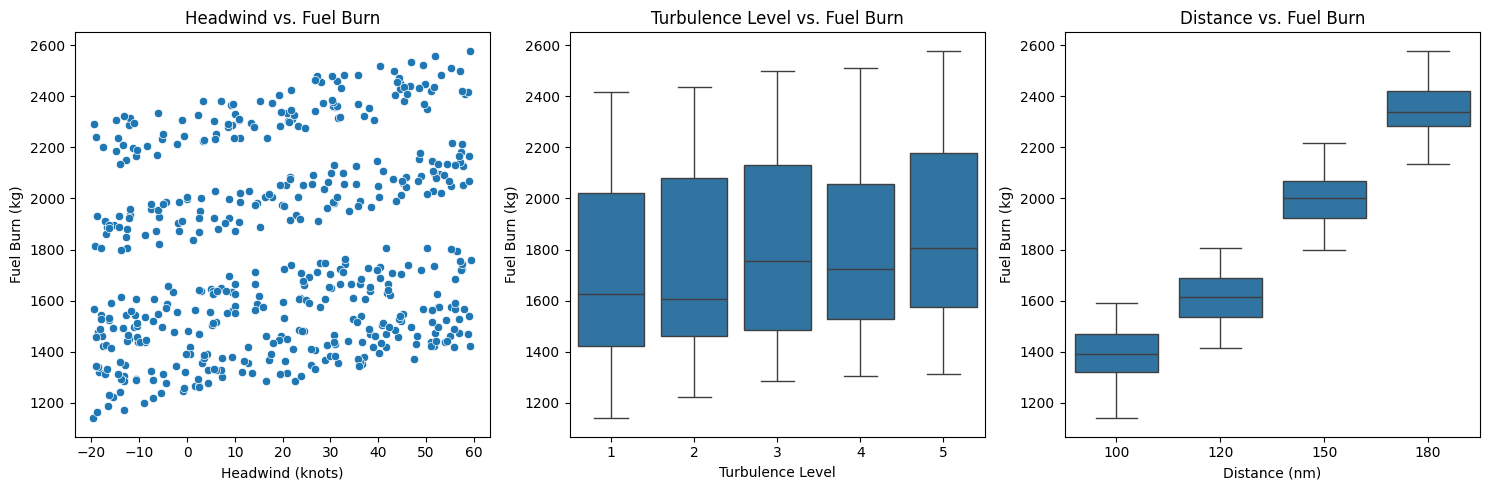

In [ ]:
plt.figure(figsize=(15, 5))

# Relationship between headwind_knots and fuel_burn_kg
plt.subplot(1, 3, 1)
sns.scatterplot(x='headwind_knots', y='fuel_burn_kg', data=df)
plt.title('Headwind vs. Fuel Burn')
plt.xlabel('Headwind (knots)')
plt.ylabel('Fuel Burn (kg)')

# Relationship between turbulence_level and fuel_burn_kg
plt.subplot(1, 3, 2)
sns.boxplot(x='turbulence_level', y='fuel_burn_kg', data=df)
plt.title('Turbulence Level vs. Fuel Burn')
plt.xlabel('Turbulence Level')
plt.ylabel('Fuel Burn (kg)')

# Relationship between distance_nm and fuel_burn_kg
plt.subplot(1, 3, 3)
sns.boxplot(x='distance_nm', y='fuel_burn_kg', data=df)
plt.title('Distance vs. Fuel Burn')
plt.xlabel('Distance (nm)')
plt.ylabel('Fuel Burn (kg)')

plt.tight_layout()
plt.show()

### Feature Correlation Analysis

Let's calculate the correlation matrix to understand the linear relationships between the features and the target variable `fuel_burn_kg`.

In [ ]:
correlation_matrix = df[['headwind_knots', 'turbulence_level', 'distance_nm', 'fuel_burn_kg']].corr()
display(correlation_matrix)

,headwind_knots,turbulence_level,distance_nm,fuel_burn_kg
headwind_knots,1.000000,-0.049918,0.009925,0.225711
turbulence_level,-0.049918,1.000000,0.016047,0.152310
distance_nm,0.009925,0.016047,1.000000,0.964167
fuel_burn_kg,0.225711,0.152310,0.964167,1.000000


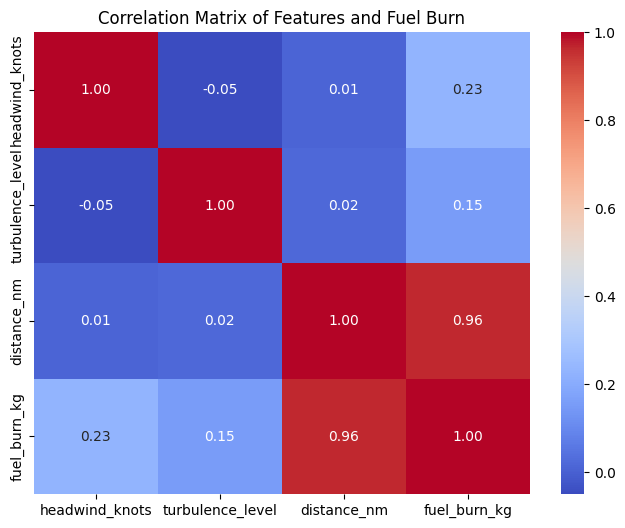

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features and Fuel Burn')
plt.show()

### Data Splitting for Training and Testing

Before training our Linear Regression model, we need to prepare the data by separating the features (input variables) from the target (output variable). Then, we will split this data into training and testing sets.

In [ ]:
from sklearn.model_selection import train_test_split

# Split features and target
X = df[['headwind_knots', 'turbulence_level', 'distance_nm']]
y = df['fuel_burn_kg']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (400, 3)
y_train shape: (400,)
X_test shape: (100, 3)
y_test shape: (100,)


### Build the Machine Learning Model (The Fuel Predictor)

Next, we will train a simple Linear Regression model. The model learns how weather conditions influence fuel consumption which will tell the dispatcher how expensive a path will be before the plane takes off.

In [ ]:
# Train the model
model = LinearRegression()
model.fit(X_train, y_train)

print(f"Model Trained! Accuracy (R2 Score): {model.score(X_test, y_test):.2f}")

# Save the trained model for our optimizer
joblib.dump(model, 'fuel_predictor_model.pkl')

Model Trained! Accuracy (R2 Score): 1.00


['fuel_predictor_model.pkl']

### The Route Optimization Engine (Dijkstra's Algorithm)

Now, we define a simple map network from Jakarta (CGK) to Surabaya (SUB) with intermediate waypoints (North Route vs. South Route). We feed today's live weather into our ML model to predict the fuel cost of each leg, then let Python find the best path.

In [ ]:
import pandas as pd

# Define waypoints and segments for the network
waypoints = ['CGK', 'WAYPOINT_A', 'WAYPOINT_B', 'WAYPOINT_C', 'WAYPOINT_D', 'SUB']
segments_data = [
    # (origin, destination, distance, avg_headwind, avg_turbulence)
    ('CGK', 'WAYPOINT_A', 120, 10, 2),
    ('CGK', 'WAYPOINT_B', 150, 20, 3),
    ('WAYPOINT_A', 'WAYPOINT_C', 100, 5, 1),
    ('WAYPOINT_A', 'WAYPOINT_D', 180, 15, 4),
    ('WAYPOINT_B', 'WAYPOINT_D', 120, 25, 2),
    ('WAYPOINT_C', 'SUB', 150, 10, 3),
    ('WAYPOINT_D', 'SUB', 100, 5, 1)
]

df_segments = pd.DataFrame(segments_data, columns=[
    'origin', 'destination', 'distance_nm', 'avg_headwind', 'avg_turbulence'
])

print("✅ Flight network segments defined in df_segments:")
display(df_segments)

✅ Flight network segments defined in df_segments:


,origin,destination,distance_nm,avg_headwind,avg_turbulence
0,CGK,WAYPOINT_A,120,10,2
1,CGK,WAYPOINT_B,150,20,3
2,WAYPOINT_A,WAYPOINT_C,100,5,1
3,WAYPOINT_A,WAYPOINT_D,180,15,4
4,WAYPOINT_B,WAYPOINT_D,120,25,2
5,WAYPOINT_C,SUB,150,10,3
6,WAYPOINT_D,SUB,100,5,1


In [ ]:
import heapq
import joblib
import pandas as pd
import networkx as nx

# Load our pre-trained model
ml_model = joblib.load('fuel_predictor_model.pkl')

# Create a directed graph using networkx
G = nx.DiGraph()

# Predict fuel cost for each segment and add to the graph as edge weights
for index, row in df_segments.iterrows():
    origin = row['origin']
    destination = row['destination']
    headwind = row['avg_headwind']
    turbulence = row['avg_turbulence']
    distance = row['distance_nm']

    # Format features into a DataFrame matching training structure for prediction
    features_df = pd.DataFrame([{
        'headwind_knots': headwind,
        'turbulence_level': turbulence,
        'distance_nm': distance
    }])
    predicted_fuel = ml_model.predict(features_df)[0]

    G.add_edge(origin, destination, weight=predicted_fuel)

# Convert networkx graph to a dictionary format suitable for our Dijkstra implementation
network_graph = {node: [] for node in G.nodes()}
for u, v, data in G.edges(data=True):
    network_graph[u].append((v, data['weight']))

# Dijkstra's Shortest Path Algorithm (Optimizing for lowest fuel)
def find_best_flight_path(graph, start, end):
    queue = [(0, start, [])]
    visited = set()

    while queue:
        (cost, node, path) = heapq.heappop(queue)
        if node not in visited:
            visited.add(node)
            path = path + [node]

            if node == end:
                return cost, path

            for next_node, weight in graph.get(node, []):
                heapq.heappush(queue, (cost + weight, next_node, path))

    return float("inf"), []

# Define start and end points based on the defined waypoints
start_point = 'CGK'
end_point = 'SUB'

# Run the flight planning optimization
optimal_fuel, flight_plan = find_best_flight_path(network_graph, start_point, end_point)

print("\n--- ✈️ OFFICIAL FLIGHT DISPATCH RELEASE ✈️ ---")
print(f"Optimal Flight Path: {' -> '.join(flight_plan)}")
print(f"Total Predicted Fuel Consumption: {optimal_fuel:.1f} kg")


--- ✈️ OFFICIAL FLIGHT DISPATCH RELEASE ✈️ ---
Optimal Flight Path: CGK -> WAYPOINT_A -> WAYPOINT_C -> SUB
Total Predicted Fuel Consumption: 4771.4 kg


### Enhance Cost Function

In order to make the optimization more realistic and useful, we will extend the cost function used by Dijkstra's algorithm to incorporate additional factors beyond just fuel burn. We can introduce a weighted cost that considers not only predicted fuel consumption but also turbulence level.

In [ ]:
# Define weights for different cost components
# These weights can be adjusted based on operational priorities
FUEL_WEIGHT = 1.0  # Priority for fuel efficiency
TURBULENCE_WEIGHT = 500.0 # Penalty for turbulence level (kg fuel equivalent per unit of turbulence)

# Create a directed graph using networkx
G_enhanced = nx.DiGraph()

# Predict fuel cost for each segment and add to the graph as edge weights
for index, row in df_segments.iterrows():
    origin = row['origin']
    destination = row['destination']
    headwind = row['avg_headwind']
    turbulence = row['avg_turbulence']
    distance = row['distance_nm']

    # Format features into a DataFrame matching training structure for prediction
    features_df = pd.DataFrame([{
        'headwind_knots': headwind,
        'turbulence_level': turbulence,
        'distance_nm': distance
    }])
    predicted_fuel = ml_model.predict(features_df)[0]

    # Calculate enhanced cost: fuel cost + turbulence penalty
    # The turbulence penalty converts turbulence level into an equivalent fuel cost
    enhanced_cost = (predicted_fuel * FUEL_WEIGHT) + (turbulence * TURBULENCE_WEIGHT)

    G_enhanced.add_edge(origin, destination, weight=enhanced_cost)

# Convert networkx graph to a dictionary format suitable for our Dijkstra implementation
network_graph_enhanced = {node: [] for node in G_enhanced.nodes()}
for u, v, data in G_enhanced.edges(data=True):
    network_graph_enhanced[u].append((v, data['weight']))

# Run the flight planning optimization with the enhanced cost function
optimal_enhanced_cost, flight_plan_enhanced = find_best_flight_path(network_graph_enhanced, start_point, end_point)

print("\n--- ✈️ OFFICIAL FLIGHT DISPATCH RELEASE (Enhanced Cost) ✈️ ---")
print(f"Optimal Flight Path (Enhanced Cost): {' -> '.join(flight_plan_enhanced)}")
print(f"Total Predicted Enhanced Cost: {optimal_enhanced_cost:.1f} (Fuel kg equivalent)")
print(f"(Note: This cost includes weighted penalties for factors like turbulence.)")



--- ✈️ OFFICIAL FLIGHT DISPATCH RELEASE (Enhanced Cost) ✈️ ---
Optimal Flight Path (Enhanced Cost): CGK -> WAYPOINT_A -> WAYPOINT_C -> SUB
Total Predicted Enhanced Cost: 7771.4 (Fuel kg equivalent)
(Note: This cost includes weighted penalties for factors like turbulence.)


### Visualize Optimal Route

Finally, let's visualize the optimal route on a graph helps in understanding the path taken and confirming the effectiveness of the algorithm. We will plot the defined waypoints and highlight the optimal path found by the enhanced Dijkstra's algorithm.

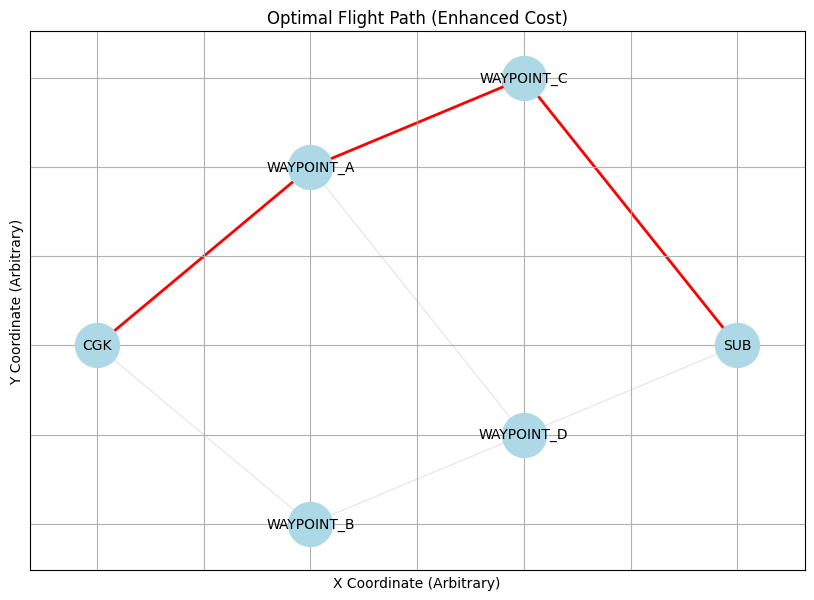

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

# Define arbitrary coordinates for waypoints for visualization purposes
# In a real-world scenario, these would be actual latitude/longitude.
waypoint_coords = {
    'CGK': (0, 0),
    'WAYPOINT_A': (1, 2),
    'WAYPOINT_B': (1, -2),
    'WAYPOINT_C': (2, 3),
    'WAYPOINT_D': (2, -1),
    'SUB': (3, 0)
}

plt.figure(figsize=(10, 7))

# Create a graph for visualization (using the enhanced graph structure)
pos = waypoint_coords

nx.draw_networkx_nodes(G_enhanced, pos, node_color='lightblue', node_size=1000)
nx.draw_networkx_labels(G_enhanced, pos, font_size=10)

# Draw all edges in light grey
nx.draw_networkx_edges(G_enhanced, pos, edge_color='lightgray', alpha=0.5, arrows=True)

# Highlight the optimal path
# Create a list of edges in the optimal path
optimal_path_edges = []
for i in range(len(flight_plan_enhanced) - 1):
    optimal_path_edges.append((flight_plan_enhanced[i], flight_plan_enhanced[i+1]))

nx.draw_networkx_edges(G_enhanced, pos, edgelist=optimal_path_edges, edge_color='red', width=2, arrows=True)

plt.title('Optimal Flight Path (Enhanced Cost)')
plt.xlabel('X Coordinate (Arbitrary)')
plt.ylabel('Y Coordinate (Arbitrary)')
plt.grid(True)
plt.show()